# Matrix Factorization

Matrix Factorization is a family of techniques used to decompose a matrix into a product of smaller or simpler matrices.

The main idea is to represent a large matrix using a combination of smaller matrices while preserving the most important information.

A general matrix factorization can be written as:

$$
A \approx BC
$$

where:

- $A$ is the original matrix
- $B$ and $C$ are smaller or structured matrices
- $\approx$ means that the factorization may be an approximation

Matrix factorization is widely used in:

- Dimensionality Reduction
- Principal Component Analysis
- Singular Value Decomposition
- Recommender Systems
- Collaborative Filtering
- Image Compression
- Noise Reduction
- Latent Feature Learning
- Natural Language Processing

In this notebook, we will focus mainly on **Singular Value Decomposition (SVD)** and **Low-Rank Matrix Approximation**.

## 1. Introduction

Many machine learning datasets can naturally be represented as matrices.

For example, suppose we have a dataset containing $n$ samples and $d$ features:

$$
X \in \mathbb{R}^{n \times d}
$$

If $n$ and $d$ are large, directly working with the complete matrix can be expensive.

Matrix factorization provides a way to represent the same information using a combination of smaller matrices.

The general idea is:

$$
X \approx UV
$$

where:

- $X$ is the original matrix
- $U$ contains one set of latent factors
- $V$ contains another set of latent factors

The factors can capture hidden or latent structure in the original data.

For example, in a recommendation system:

$$
\text{User-Item Matrix}
\approx
\text{User Factors}
\times
\text{Item Factors}
$$

This allows us to discover hidden characteristics such as:

- user preferences
- item characteristics
- latent topics
- hidden dimensions

## 2. Why Matrix Factorization?

A large matrix may contain redundant information.

For example, a dataset may contain hundreds of features, but many of those features may be strongly correlated.

Matrix factorization can identify a smaller number of important latent factors.

Suppose:

$$
X \in \mathbb{R}^{1000 \times 100}
$$

Instead of working directly with all 100 features, we may approximate the matrix using only 10 latent factors:

$$
X \approx UV
$$

where:

$$
U \in \mathbb{R}^{1000 \times 10}
$$

and:

$$
V \in \mathbb{R}^{10 \times 100}
$$

The original matrix contains:

$$
1000 \times 100 = 100000
$$

values.

The factorized representation contains:

$$
1000 \times 10 + 10 \times 100 = 11000
$$

values.

Therefore, matrix factorization can provide a much more compact representation.

The important idea is:

**A large matrix can sometimes be represented accurately using a much smaller number of latent factors.**

## 3. Matrix Representation

Consider a matrix:

$$
A =
\begin{bmatrix}
a_{11} & a_{12} & a_{13} \\
a_{21} & a_{22} & a_{23} \\
a_{31} & a_{32} & a_{33}
\end{bmatrix}
$$

Matrix factorization attempts to express $A$ as a product of matrices.

For example:

$$
A = BC
$$

where:

$$
B \in \mathbb{R}^{m \times k}
$$

and:

$$
C \in \mathbb{R}^{k \times n}
$$

Therefore:

$$
A \in \mathbb{R}^{m \times n}
$$

The value of $k$ determines the number of latent factors.

If:

$$
k < \min(m,n)
$$

then the factorized representation uses fewer dimensions than the original matrix.

This is the foundation of **low-rank matrix approximation**.

## 4. Rank of a Matrix

The rank of a matrix is the number of linearly independent rows or columns.

For a matrix:

$$
A \in \mathbb{R}^{m \times n}
$$

the rank satisfies:

$$
\operatorname{rank}(A) \leq \min(m,n)
$$

For example:

$$
A =
\begin{bmatrix}
1 & 2 \\
2 & 4
\end{bmatrix}
$$

The second row is a multiple of the first row.

Therefore:

$$
\operatorname{rank}(A) = 1
$$

even though the matrix has two rows and two columns.

Rank is important because matrix factorization attempts to represent a matrix using a smaller number of independent components.

A matrix with a small rank contains a significant amount of redundancy.

## 5. Low-Rank Matrix Approximation

A low-rank approximation represents a matrix using fewer latent dimensions.

Suppose:

$$
A \in \mathbb{R}^{m \times n}
$$

has rank $r$.

Instead of using the complete matrix, we can construct an approximation of rank $k$ where:

$$
k < r
$$

The approximation is written as:

$$
A_k \approx A
$$

The goal is to choose $A_k$ such that it preserves as much important information from $A$ as possible.

Low-rank approximation is useful for:

- dimensionality reduction
- compression
- denoising
- visualization
- recommendation systems
- image compression
- feature extraction

SVD provides one of the most powerful methods for constructing a low-rank approximation.

# 6. Singular Value Decomposition

Singular Value Decomposition (SVD) is one of the most important matrix factorization techniques.

For a matrix:

$$
A \in \mathbb{R}^{m \times n}
$$

SVD decomposes the matrix as:

$$
A = U\Sigma V^T
$$

where:

- $U$ is the left singular vector matrix
- $\Sigma$ is the diagonal matrix of singular values
- $V^T$ is the transpose of the right singular vector matrix

The dimensions are:

$$
U \in \mathbb{R}^{m \times m}
$$

$$
\Sigma \in \mathbb{R}^{m \times n}
$$

$$
V^T \in \mathbb{R}^{n \times n}
$$

The singular values are arranged in descending order:

$$
\sigma_1 \geq \sigma_2 \geq \sigma_3 \geq \cdots \geq 0
$$

The largest singular values generally correspond to the most important directions of variation in the data.

## 7. Intuition Behind SVD

SVD can be understood as transforming a matrix through three stages.

$$
A = U\Sigma V^T
$$

### Step 1 — $V^T$

The matrix $V^T$ represents a rotation or change of coordinate system.

It identifies important directions in the original feature space.

### Step 2 — $\Sigma$

The matrix $\Sigma$ scales those directions.

The diagonal values:

$$
\sigma_1,\sigma_2,\sigma_3,\ldots
$$

represent the importance or strength of each direction.

### Step 3 — $U$

The matrix $U$ maps the transformed representation into the output space.

Therefore, conceptually:

$$
\text{Original Matrix}
\rightarrow
\text{Rotate}
\rightarrow
\text{Scale}
\rightarrow
\text{Rotate}
$$

This decomposition allows us to identify the most important directions in a matrix.

# 8. SVD with NumPy

In [1]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([
    [3, 2, 1],
    [4, 5, 6],
    [7, 8, 9]
])

A

array([[3, 2, 1],
       [4, 5, 6],
       [7, 8, 9]])

In [2]:
U, S, Vt = np.linalg.svd(A)

print("U:")
print(U)

print("\nSingular values:")
print(S)

print("\nV^T:")
print(Vt)

U:
[[-0.19724037  0.95085972 -0.23866719]
 [-0.52179623 -0.30792418 -0.79555728]
 [-0.82995478 -0.03238037  0.5568901 ]]

Singular values:
[1.67819525e+01 1.83468573e+00 3.91293278e-17]

V^T:
[[-0.50581656 -0.57461133 -0.64340611]
 [ 0.75992298  0.0561707  -0.64758159]
 [ 0.40824829 -0.81649658  0.40824829]]


## 9. Understanding the Dimensions

In [3]:
print("Shape of A:", A.shape)
print("Shape of U:", U.shape)
print("Shape of S:", S.shape)
print("Shape of Vt:", Vt.shape)

Shape of A: (3, 3)
Shape of U: (3, 3)
Shape of S: (3,)
Shape of Vt: (3, 3)


The NumPy function `np.linalg.svd()` returns:

$$
U, S, V^T
$$

However, NumPy stores the singular values as a one-dimensional array rather than as the full diagonal matrix $\Sigma$.

Therefore:

```text
U      → Left singular vectors
S      → Singular values
Vt     → Right singular vectors transposed


---

# 10. Reconstructing the Matrix


In [4]:
Sigma = np.zeros_like(A, dtype=float)

np.fill_diagonal(Sigma, S)

print(Sigma)

[[1.67819525e+01 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 1.83468573e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 3.91293278e-17]]


In [5]:
A_reconstructed = U @ Sigma @ Vt

print(A_reconstructed)

[[3. 2. 1.]
 [4. 5. 6.]
 [7. 8. 9.]]


In [6]:
print("Original Matrix:")
print(A)

print("\nReconstructed Matrix:")
print(A_reconstructed)

print("\nReconstruction Error:")
print(np.linalg.norm(A - A_reconstructed))

Original Matrix:
[[3 2 1]
 [4 5 6]
 [7 8 9]]

Reconstructed Matrix:
[[3. 2. 1.]
 [4. 5. 6.]
 [7. 8. 9.]]

Reconstruction Error:
7.188211828540968e-15


## 11. Singular Values

The singular values tell us how much information or variation is associated with each singular direction.

They are ordered as:

$$
\sigma_1 \geq \sigma_2 \geq \sigma_3 \geq \cdots
$$

If the first few singular values are much larger than the remaining values, then most of the information in the matrix can be represented using only those first few components.

For example:

$$
\sigma_1 = 20
$$

$$
\sigma_2 = 5
$$

$$
\sigma_3 = 0.5
$$

In this case, the first singular value contains much more information than the third.

This motivates **low-rank approximation**.

## 12. Visualizing Singular Values

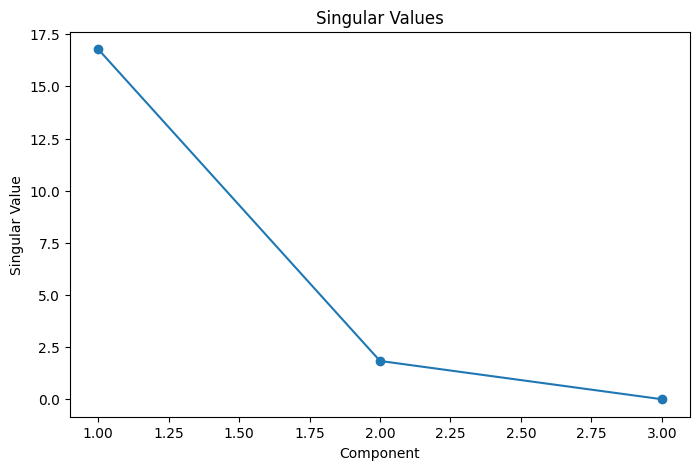

In [7]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(S) + 1),
    S,
    marker="o"
)

plt.xlabel("Component")
plt.ylabel("Singular Value")
plt.title("Singular Values")

plt.show()

# 13. Low-Rank Approximation Using SVD

Suppose:

$$
A = U\Sigma V^T
$$

Instead of using all singular values, we keep only the first $k$ largest singular values.

Then:

$$
A_k = U_k\Sigma_kV_k^T
$$

where:

- $U_k$ contains the first $k$ columns of $U$
- $\Sigma_k$ contains the first $k$ singular values
- $V_k^T$ contains the first $k$ rows of $V^T$

The resulting matrix $A_k$ is a rank-$k$ approximation of $A$.

The smaller $k$ is, the more compressed the representation becomes.

However, choosing a very small $k$ may result in information loss.

## 14. Implement Low-Rank Approximation

In [8]:
def low_rank_approximation(A, k):
    U, S, Vt = np.linalg.svd(A, full_matrices=False)

    Uk = U[:, :k]
    Sk = np.diag(S[:k])
    Vtk = Vt[:k, :]

    return Uk @ Sk @ Vtk

In [9]:
A_k = low_rank_approximation(A, k=2)

print(A_k)

[[3. 2. 1.]
 [4. 5. 6.]
 [7. 8. 9.]]


## 15. Reconstruction Error

A low-rank approximation does not necessarily reproduce the original matrix exactly.

The difference between the original matrix and its approximation can be measured using reconstruction error.

A common measure is the Frobenius norm:

$$
\|A-A_k\|_F
$$

where:

$$
\|A\|_F =
\sqrt{
\sum_{i=1}^{m}
\sum_{j=1}^{n}
a_{ij}^2
}
$$

A smaller reconstruction error means that the approximation is closer to the original matrix.

In [10]:
error = np.linalg.norm(A - A_k, ord="fro")

print("Reconstruction Error:", error)

Reconstruction Error: 7.188211828540968e-15


## 16. Rank vs Information

Increasing the number of components generally improves reconstruction accuracy.

For example:

$$
A_1 = U_1\Sigma_1V_1^T
$$

uses one component.

While:

$$
A_2 = U_2\Sigma_2V_2^T
$$

uses two components.

And:

$$
A_r = U_r\Sigma_rV_r^T
$$

uses all available components.

Generally:

$$
\text{Reconstruction Error}(A_1)
\geq
\text{Reconstruction Error}(A_2)
\geq
\cdots
$$

Therefore, there is a trade-off:

**More components → More information → Less compression**

**Fewer components → Less information → More compression**

## 17. Explained Variance Ratio

Singular values can also be used to estimate how much information is captured by each component.

The contribution of singular value $\sigma_i$ can be measured using:

$$
\frac{\sigma_i^2}
{\sum_j \sigma_j^2}
$$

The cumulative explained variance for the first $k$ components is:

$$
\text{Cumulative Explained Variance}
=
\frac{
\sum_{i=1}^{k}\sigma_i^2
}{
\sum_{j=1}^{r}\sigma_j^2
}
$$

where $r$ is the number of non-zero singular values.

This helps us decide how many components should be retained.

In [11]:
explained_variance_ratio = (S ** 2) / np.sum(S ** 2)

cumulative_variance = np.cumsum(explained_variance_ratio)

print("Explained Variance Ratio:")
print(explained_variance_ratio)

print("\nCumulative Explained Variance:")
print(cumulative_variance)

Explained Variance Ratio:
[9.88189222e-01 1.18107779e-02 5.37229577e-36]

Cumulative Explained Variance:
[0.98818922 1.         1.        ]


## 18. Choosing Number of Components

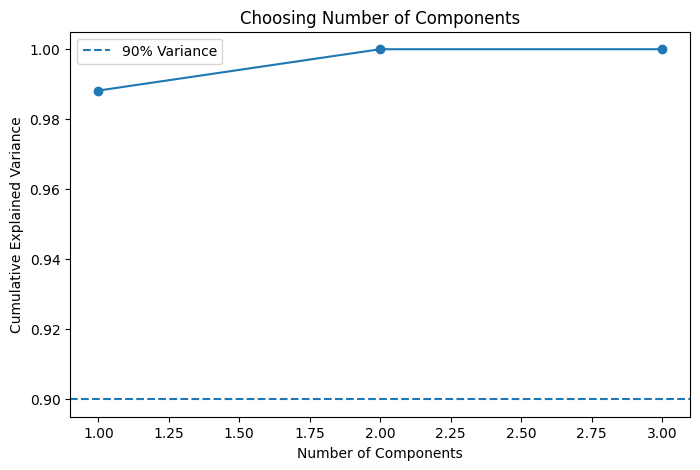

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    y=0.90,
    linestyle="--",
    label="90% Variance"
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Choosing Number of Components")

plt.legend()

plt.show()

# 19. Matrix Factorization for Dimensionality Reduction

Suppose the original dataset is:

$$
X \in \mathbb{R}^{n \times d}
$$

SVD decomposes it as:

$$
X = U\Sigma V^T
$$

If we retain only $k$ components:

$$
X_k = U_k\Sigma_kV_k^T
$$

The reduced representation can be obtained using:

$$
Z = U_k\Sigma_k
$$

Therefore:

$$
Z \in \mathbb{R}^{n \times k}
$$

Instead of representing each sample using $d$ features, we represent it using only $k$ latent dimensions.

This is one of the reasons SVD is useful for dimensionality reduction.

# 20. Relationship Between SVD and PCA

Principal Component Analysis (PCA) and SVD are closely related.

For centered data:

$$
X_c = X - \mu
$$

PCA can be computed using the SVD of the centered data:

$$
X_c = U\Sigma V^T
$$

The principal directions are represented by the rows of:

$$
V^T
$$

The transformed data is:

$$
Z = X_cV
$$

which is also:

$$
Z = U\Sigma
$$

Therefore, SVD provides an efficient mathematical method for computing PCA.

However, matrix factorization is broader than PCA.

SVD can be applied to general matrices, while PCA specifically focuses on finding directions of maximum variance in centered data.

## 21. Practical PCA-Style Example

In [13]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

iris = load_iris()

X = iris.data
y = iris.target

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Original Shape:", X_scaled.shape)

Original Shape: (150, 4)


In [14]:
U, S, Vt = np.linalg.svd(X_scaled, full_matrices=False)

print("U Shape:", U.shape)
print("S Shape:", S.shape)
print("Vt Shape:", Vt.shape)

U Shape: (150, 4)
S Shape: (4,)
Vt Shape: (4, 4)


In [15]:
X_reduced = U[:, :2] @ np.diag(S[:2])

print("Reduced Shape:", X_reduced.shape)

Reduced Shape: (150, 2)


## 22. Visualizing Reduced Data

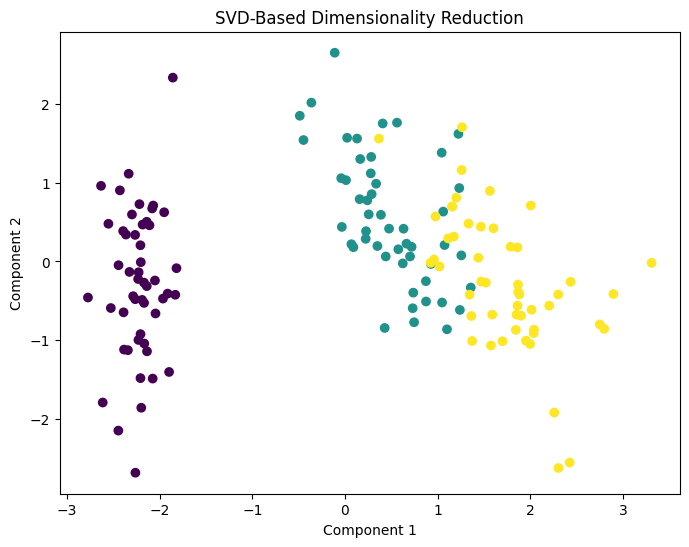

In [16]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    c=y
)

plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("SVD-Based Dimensionality Reduction")

plt.show()

# 23. Matrix Factorization in Recommender Systems

Matrix factorization is especially important in recommendation systems.

Suppose we have a user-item rating matrix:

$$
R \in \mathbb{R}^{m \times n}
$$

where:

- $m$ = number of users
- $n$ = number of items
- $R_{ij}$ = rating given by user $i$ to item $j$

For example:

$$
R =
\begin{bmatrix}
5 & 4 & ? & 1 \\
4 & ? & 2 & 1 \\
1 & 2 & 5 & ? \\
? & 1 & 4 & 5
\end{bmatrix}
$$

The question marks represent missing ratings.

Matrix factorization assumes that user preferences can be represented using a smaller number of latent factors.

We approximate:

$$
R \approx UV^T
$$

where:

$$
U \in \mathbb{R}^{m \times k}
$$

and:

$$
V \in \mathbb{R}^{n \times k}
$$

Here, $k$ represents the number of latent factors.

The predicted rating is:

$$
\hat{R}_{ij} = U_iV_j^T
$$

This allows the model to predict ratings that the user has not provided.

## 24. Recommender System Intuition

The latent factors do not necessarily have explicit names.

For a movie recommendation system, hidden factors might approximately represent:

- action preference
- comedy preference
- drama preference
- science-fiction preference
- popularity preference

For example, a user may have a latent representation:

$$
U_i =
[0.9,\;0.2,\;0.8]
$$

and a movie may have:

$$
V_j =
[0.8,\;0.1,\;0.9]
$$

Their dot product measures how compatible the user and movie are:

$$
\hat{R}_{ij}=U_iV_j^T
$$

A higher value suggests that the user may be more interested in the item.

# 25. Matrix Factorization Objective

In recommendation systems, the factors can be learned by minimizing the difference between observed ratings and predicted ratings.

A common objective is:

$$
\min_{U,V}
\sum_{(i,j)\in\Omega}
\left(
R_{ij}-U_iV_j^T
\right)^2
$$

where:

$$
\Omega
$$

represents the set of observed user-item ratings.

Regularization is often added to prevent overfitting:

$$
\min_{U,V}
\sum_{(i,j)\in\Omega}
\left(
R_{ij}-U_iV_j^T
\right)^2
+
\lambda
\left(
\|U\|_F^2+\|V\|_F^2
\right)
$$

where:

- $\lambda$ controls regularization strength
- $\|U\|_F^2$ penalizes large values in $U$
- $\|V\|_F^2$ penalizes large values in $V$

This is the foundation of many collaborative filtering approaches.

# 26. Image Compression with SVD

An image can be represented as a matrix of pixel values.

For a grayscale image:

$$
I \in \mathbb{R}^{m \times n}
$$

SVD decomposes the image:

$$
I = U\Sigma V^T
$$

Instead of storing all singular values, we can keep only the first $k$.

Then:

$$
I_k = U_k\Sigma_kV_k^T
$$

If $k$ is much smaller than the original dimensions, the image can be represented using fewer values.

Therefore:

**SVD can be used for image compression while maintaining the most important visual structure.**

## 27. Image Compression Example

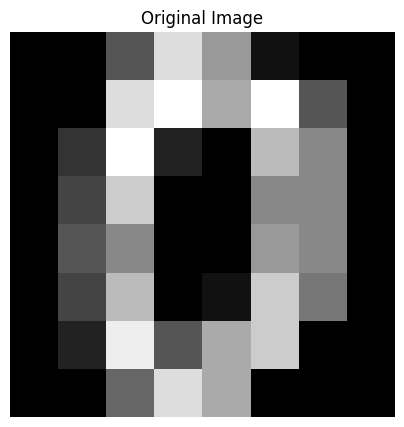

In [17]:
from sklearn.datasets import load_digits

digits = load_digits()

image = digits.images[0]

plt.figure(figsize=(5, 5))

plt.imshow(image, cmap="gray")

plt.axis("off")
plt.title("Original Image")

plt.show()

In [18]:
U, S, Vt = np.linalg.svd(image, full_matrices=False)

print("Image Shape:", image.shape)
print("Number of Singular Values:", len(S))

Image Shape: (8, 8)
Number of Singular Values: 8


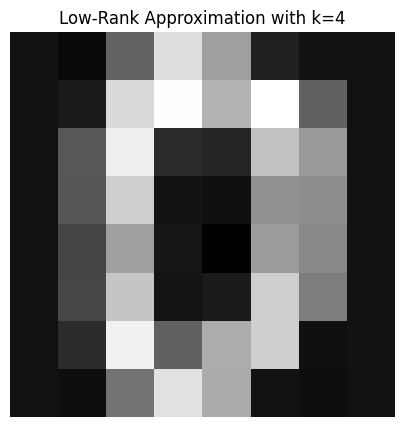

In [19]:
k = 4

compressed_image = (
    U[:, :k]
    @ np.diag(S[:k])
    @ Vt[:k, :]
)

plt.figure(figsize=(5, 5))

plt.imshow(compressed_image, cmap="gray")

plt.axis("off")
plt.title(f"Low-Rank Approximation with k={k}")

plt.show()

## 28. Increasing the Rank

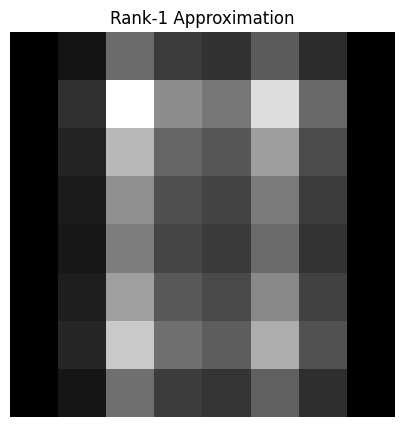

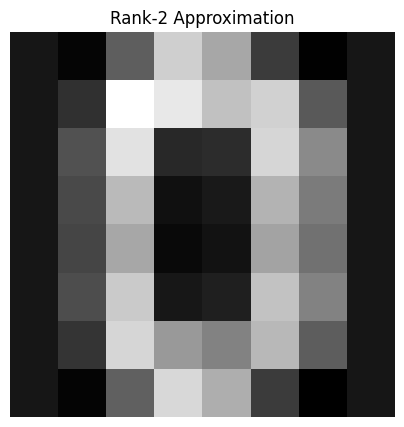

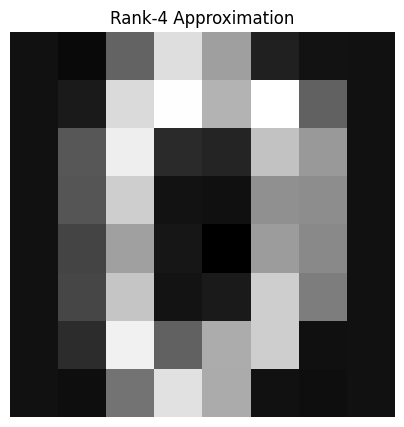

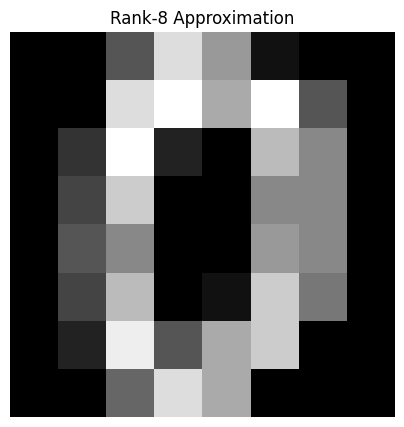

In [20]:
components = [1, 2, 4, 8]

for k in components:

    reconstructed = (
        U[:, :k]
        @ np.diag(S[:k])
        @ Vt[:k, :]
    )

    plt.figure(figsize=(5, 5))

    plt.imshow(reconstructed, cmap="gray")

    plt.axis("off")
    plt.title(f"Rank-{k} Approximation")

    plt.show()

# 29. Advantages of Matrix Factorization

### 1. Dimensionality Reduction

Matrix factorization can represent data using fewer latent dimensions.

### 2. Data Compression

A matrix can sometimes be stored using a much smaller factorized representation.

### 3. Noise Reduction

Small singular values can sometimes correspond to noise.

Removing them can produce a cleaner approximation.

### 4. Feature Extraction

Matrix factorization can discover latent structure that is not directly visible in the original features.

### 5. Recommendation Systems

Matrix factorization is widely used for collaborative filtering.

### 6. Image Compression

SVD can represent images using a small number of important components.

### 7. Mathematical Flexibility

SVD works with rectangular matrices and does not require a square matrix.

# 30. Disadvantages of Matrix Factorization

### 1. Computational Cost

SVD can be computationally expensive for extremely large matrices.

### 2. Interpretation Can Be Difficult

Latent factors may not always have an obvious real-world interpretation.

### 3. Information Loss

Low-rank approximation intentionally removes some information.

If too few components are selected, important information may be lost.

### 4. Choosing the Rank

Selecting an appropriate number of latent factors can be difficult.

### 5. Sparse Data Challenges

In recommendation systems, most user-item combinations may be missing.

Specialized methods are often required for sparse matrices.

### 6. Overfitting

Learned factorization models can overfit the observed data.

Regularization is commonly used to reduce this problem.

### 7. Scaling Issues

Very large matrices may require specialized algorithms or randomized methods.

# 31. Matrix Factorization vs PCA

Matrix factorization is a broad family of techniques.

PCA is a specific dimensionality-reduction technique that can be efficiently computed using SVD.

### Matrix Factorization

Focus:

- decomposing matrices
- latent factor representation
- compression
- recommendation systems
- reconstruction

### PCA

Focus:

- finding directions of maximum variance
- dimensionality reduction
- feature transformation
- visualization

The relationship can be summarized as:

$$
\text{Centered Data}
\rightarrow
\text{SVD}
\rightarrow
\text{Principal Components}
$$

Therefore:

**SVD is a matrix factorization technique, while PCA is a statistical dimensionality-reduction method that can be computed using SVD.**

# 32. SVD vs Eigenvalue Decomposition

SVD and eigenvalue decomposition are related but different techniques.

### Eigenvalue Decomposition

For a square matrix $A$:

$$
A = Q\Lambda Q^{-1}
$$

This requires an appropriate square matrix.

### Singular Value Decomposition

For any matrix:

$$
A = U\Sigma V^T
$$

SVD works for:

- square matrices
- rectangular matrices
- rank-deficient matrices

SVD is therefore more generally applicable.

For symmetric positive semidefinite matrices, the relationship between eigenvalues and singular values becomes especially direct.

For many machine learning applications, SVD is preferred because it is numerically stable and naturally handles rectangular data matrices.

# 33. Applications of Matrix Factorization

Matrix factorization is used in many areas of machine learning and data science.

### Machine Learning

- dimensionality reduction
- latent feature extraction
- preprocessing

### Recommendation Systems

- collaborative filtering
- user preference modeling
- item representation

### Computer Vision

- image compression
- image reconstruction
- noise reduction

### Natural Language Processing

- document-term matrix decomposition
- latent semantic analysis
- topic discovery

### Data Mining

- hidden structure discovery
- dimensionality reduction
- sparse data analysis

### Signal Processing

- noise filtering
- signal reconstruction
- low-rank representation

# 34. Important Concepts to Remember

The most important concepts from this notebook are:

1. Matrix factorization decomposes a matrix into simpler matrices.

2. A general factorization can be represented as:

$$
A \approx BC
$$

3. SVD decomposes a matrix as:

$$
A = U\Sigma V^T
$$

4. Singular values are ordered from largest to smallest.

5. Large singular values generally capture the most important structure.

6. Keeping only the first $k$ singular values produces a low-rank approximation:

$$
A_k = U_k\Sigma_kV_k^T
$$

7. Low-rank approximation provides a trade-off between compression and reconstruction accuracy.

8. SVD can be used for dimensionality reduction.

9. SVD is closely related to PCA.

10. Matrix factorization is widely used in recommender systems.

11. Matrix factorization can also be used for image compression and denoising.

12. Choosing the number of latent factors is an important modeling decision.

# 35. Final Practical Example

We will now combine the main concepts.

We will:

1. Load a dataset.
2. Standardize the features.
3. Apply SVD.
4. Inspect singular values.
5. Calculate explained variance.
6. Reduce the dimensionality.
7. Reconstruct the data.
8. Calculate reconstruction error.

In [21]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

iris = load_iris()

X = iris.data

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Original Shape:", X_scaled.shape)

Original Shape: (150, 4)


In [22]:
U, S, Vt = np.linalg.svd(
    X_scaled,
    full_matrices=False
)

print("U Shape:", U.shape)
print("S Shape:", S.shape)
print("Vt Shape:", Vt.shape)

U Shape: (150, 4)
S Shape: (4,)
Vt Shape: (4, 4)


In [23]:
explained_variance_ratio = (
    S ** 2
) / np.sum(S ** 2)

cumulative_variance = np.cumsum(
    explained_variance_ratio
)

for i, value in enumerate(
    cumulative_variance,
    start=1
):
    print(
        f"Components: {i}, "
        f"Cumulative Variance: {value:.4f}"
    )

Components: 1, Cumulative Variance: 0.7296
Components: 2, Cumulative Variance: 0.9581
Components: 3, Cumulative Variance: 0.9948
Components: 4, Cumulative Variance: 1.0000


In [24]:
k = 2

X_reduced = (
    U[:, :k]
    @ np.diag(S[:k])
)

print("Reduced Data Shape:", X_reduced.shape)

Reduced Data Shape: (150, 2)


In [25]:
X_reconstructed = (
    U[:, :k]
    @ np.diag(S[:k])
    @ Vt[:k, :]
)

reconstruction_error = np.linalg.norm(
    X_scaled - X_reconstructed,
    ord="fro"
)

print(
    "Reconstruction Error:",
    reconstruction_error
)

Reconstruction Error: 5.012061132906316


## 36. Final Visualization

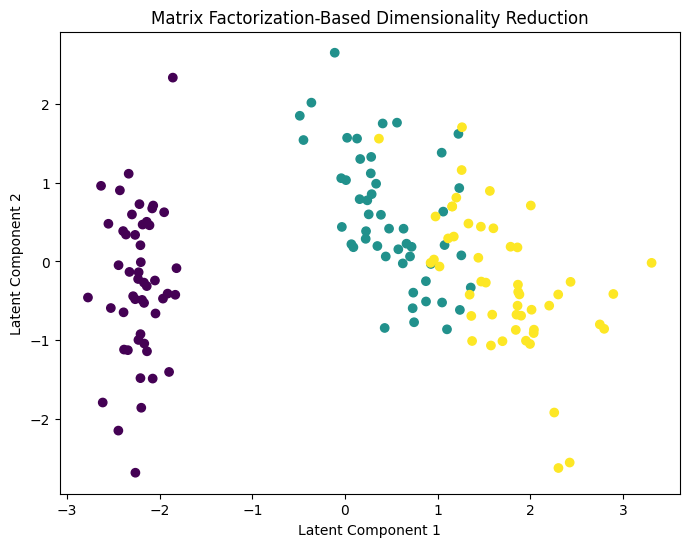

In [26]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    c=iris.target
)

plt.xlabel("Latent Component 1")
plt.ylabel("Latent Component 2")
plt.title("Matrix Factorization-Based Dimensionality Reduction")

plt.show()

# 37. Final Summary

Matrix factorization provides a powerful way to represent complex matrices using simpler latent representations.

The central idea is:

$$
A \approx BC
$$

One of the most important matrix factorization methods is Singular Value Decomposition:

$$
A = U\Sigma V^T
$$

The singular values indicate the importance of different latent directions.

By retaining only the largest $k$ singular values, we obtain:

$$
A_k = U_k\Sigma_kV_k^T
$$

This provides a low-rank approximation.

Matrix factorization is useful for:

- dimensionality reduction
- feature extraction
- data compression
- image compression
- noise reduction
- recommender systems
- collaborative filtering
- latent structure discovery

The key trade-off is:

$$
\text{Fewer Components}
\rightarrow
\text{More Compression}
\rightarrow
\text{More Information Loss}
$$

while:

$$
\text{More Components}
\rightarrow
\text{Less Compression}
\rightarrow
\text{Better Reconstruction}
$$

The most important concept to remember is that **matrix factorization attempts to discover a compact latent representation of a matrix while preserving its important structure.**

06_Matrix_Factorization.ipynb

1. Introduction
2. Why Matrix Factorization?
3. Matrix Representation
4. Rank of a Matrix
5. Low-Rank Matrix Approximation
6. Singular Value Decomposition
7. Intuition Behind SVD
8. SVD with NumPy
9. Understanding the Dimensions
10. Reconstructing the Matrix
11. Singular Values
12. Visualizing Singular Values
13. Low-Rank Approximation Using SVD
14. Implement Low-Rank Approximation
15. Reconstruction Error
16. Rank vs Information
17. Explained Variance Ratio
18. Choosing Number of Components
19. Matrix Factorization for Dimensionality Reduction
20. Relationship Between SVD and PCA
21. Practical PCA-Style Example
22. Visualizing Reduced Data
23. Matrix Factorization in Recommender Systems
24. Recommender System Intuition
25. Matrix Factorization Objective
26. Image Compression with SVD
27. Image Compression Example
28. Increasing the Rank
29. Advantages
30. Disadvantages
31. Matrix Factorization vs PCA
32. SVD vs Eigenvalue Decomposition
33. Applications
34. Important Concepts to Remember
35. Final Practical Example
36. Final Visualization
37. Final Summary